# OSNet — Zhou et al. (ICCV 2019), explained

Paper: *Omni-Scale Feature Learning for Person Re-Identification*.

Goal of this notebook: **understand re-identification**, and understand the one architectural idea
OSNet contributes to it — omni-scale features fused by a unified aggregation gate.
Anything PyTorch already provides (`nn.Conv2d`, `nn.BatchNorm2d`, `CrossEntropyLoss`, `SGD`,
`DataLoader`) is used as-is.

The paper's task is person ReID on Market1501. Here it is swapped for **individual tiger
re-identification** on the [ATRW](https://cvwc2019.github.io/challenge.html) reid split — the same
images `n4` used, but asking a fundamentally different question.

---

## If you are new to re-ID, read this part first

`n4` (ResNet) did **classification**: 107 tiger identities, one output neuron per identity, and the
answer to "which tiger is this?" came from `argmax`. That works, and it is genuinely useful — but it
has a hard structural limit:

> A softmax classifier can only ever name identities that existed **when it was trained**.

Add tiger #108 and the network has no output neuron for it. The 107 probabilities still sum to 1, so
the new tiger gets confidently assigned to one of the old ones. You must relabel, resize the final
layer, and retrain. On a farm where animals arrive and leave every month, that is not a system.

Re-ID replaces the question. Instead of *"which of my known classes is this?"* it asks
*"how similar are these two images?"*:

```
   classification:   image ---> network ---> 107 scores ---> argmax ---> "tiger 42"
   re-ID:            image ---> network ---> 512-d vector
                                                  |
                     compare (cosine / L2) against a database of stored vectors
                                                  |
                                        nearest match ---> "tiger 42"
                                        nothing close  ---> "new tiger, enrol it"
```

Three consequences worth holding onto, because they drive every design decision below:

1. **The classifier head is scaffolding.** It is trained, then deleted. What ships is the backbone
   and the 512-d vector it produces (the *embedding*).
2. **Identities live in a database, not in the weights.** Adding tiger #108 means appending a row to
   a table. No retraining.
3. **Therefore the test set must contain identities the model has never seen.** If you evaluate on
   the same identities you trained on, you are measuring classification and calling it re-ID. `n4`
   split by *image*; this notebook splits by *identity*. That single change is the most important
   line of code in the notebook.

The vocabulary you need (full list in Section 6):

| Term | Meaning |
|---|---|
| **embedding** | the 512-d output vector; distances between embeddings are the whole point |
| **query** | the image you are trying to identify |
| **gallery** | the database of already-enrolled images/embeddings you search |
| **rank-1 / CMC** | fraction of queries whose nearest gallery neighbour has the right identity |
| **mAP** | precision averaged over *all* correct gallery matches, not just the first |
| **closed-set** | every test identity was seen in training (what `n4` measured) |
| **open-set** | test identities may be brand new (the realistic setting, and this notebook) |

**Layout**
1. Load the data — identity-disjoint split, query/gallery, PK batches
2. Helper functions, and why each one exists
3. The architecture — Lite 3×3, the omni-scale block, the unified aggregation gate
4. Train
5. Predict and validate — retrieval, not classification
6. Glossary

**What the paper specifies** (kept): depthwise-separable "Lite 3×3" convolutions in
pointwise→depthwise order, the T=4 multi-stream omni-scale residual block, the unified aggregation
gate shared across streams, the conv1→conv5 stage layout of Table 1, 512-d feature vector, softmax
cross-entropy with label smoothing, random flip + random erasing, SGD.

**Where this adapts** (flagged, on purpose):
- **Input is transposed.** The paper uses 256×128 (H×W) because people stand upright. Tiger crops
  are landscape, so this notebook uses **128×256**. Every feature-map size below is therefore the
  transpose of Table 1's.
- **Fewer epochs.** The paper trains from scratch for 350 epochs. Default here is 60 so the
  notebook finishes; expect numbers below the paper's, and treat 350 as the ablation.
- **Triplet loss is optional and off by default.** The paper uses cross-entropy + label smoothing
  *only*. Triplet loss is implemented in Section 3 behind a flag because it is the standard modern
  addition and a clean one-variable ablation — but it is **not** what this paper did.
- **No camera IDs.** Market1501 evaluation excludes gallery images from the same camera as the
  query. ATRW's reid split has no camera annotation, so that filter is dropped. This makes the
  numbers slightly optimistic; it is a real simplification, not a detail.
- **`fc` is a plain linear layer.** The official code has a BN+ReLU+dropout variant of the fc block;
  ours is the simple version.

# Section 1 — Loading the data

Same files as `n4` — see `n4` Section 1 for the directory layout:

```
benchmarks/atrw_dataset_reid_tiger/
├── atrw_anno_reid_train/reid_list_train.csv   id, filename  (labelled)
└── atrw_reid_train/train/*.jpg
```

**What changes, and why it changes everything.**

`n4` used a *stratified* split: every tiger appeared in both train and val, just with different
photos. That is the right split for classification and the wrong split for re-ID — it lets the
network memorise "tiger 42 looks like *this*" instead of learning "these two crops show the same
animal".

Here the split is **identity-disjoint**:

```
107 tiger identities
   ├── ~85 identities  -> TRAIN      (the network sees these, and only these)
   └── ~22 identities  -> EVALUATION (never seen during training)
                             ├── 1 image per identity  -> QUERY
                             └── the rest              -> GALLERY
```

At evaluation time we embed every query and every gallery image, sort the gallery by distance to
each query, and ask whether the top hit has the right identity. **The classifier head plays no part
in this.** It cannot: it has no output neuron for any of these tigers.

Transforms follow the paper: random horizontal flip and random erasing for training, deterministic
resize for evaluation, ImageNet channel normalization.

> ⚠️ **Horizontal flip on striped animals.** The paper uses it for people, where left/right is not
> identity-bearing. A tiger's stripe pattern is asymmetric — its left flank is not its right flank.
> Flip is left on here to stay paper-faithful, but turning it off is the first ablation in the Next
> steps table, and on a real cattle deployment it is the one I would test first.

In [1]:
import csv
import os
import random
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset, Sampler
from torchvision import transforms

# Prevent worker crashes on partially corrupted JPEG files.
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)
random.seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_reid_tiger")
TRAIN_IMG_DIR = DATA_ROOT / "atrw_reid_train" / "train"
TRAIN_CSV = DATA_ROOT / "atrw_anno_reid_train" / "reid_list_train.csv"

print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.1+cu126 | device: cuda


In [2]:
# Paper input is 256x128 (H x W) for upright people. Tigers are landscape -> transposed.
IMG_H, IMG_W = 128, 256

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.RandomHorizontalFlip(p=0.5),        # see the warning above
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.4), value="random"),   # paper's augmentation
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


def read_labels(csv_path):
    """CSV rows are 'id,filename' -> [(filename, id), ...]."""
    rows = []
    with open(csv_path, newline="") as f:
        for tiger_id, filename in csv.reader(f):
            rows.append((filename, int(tiger_id)))
    return rows


class TigerReIDDataset(Dataset):
    """One row = one photo of one tiger. Returns (image, label). Label is the *contiguous*
    training index for train, and the raw tiger id for query/gallery (where labels are only
    ever compared for equality, never fed to a classifier)."""

    def __init__(self, samples, img_dir, label_map, transform):
        self.samples = samples
        self.img_dir = img_dir
        self.label_map = label_map        # tiger_id -> int; identity map for eval sets
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        filename, tiger_id = self.samples[i]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), self.label_map[tiger_id]


def identity_disjoint_split(rows, n_eval_ids=22, min_imgs=4, seed=0):
    """THE key difference from n4. Split by *identity*, not by image, so evaluation identities
    are ones the network has never been trained on. Identities with too few photos are kept in
    train, because an eval identity needs at least one query + one gallery image."""
    by_id = {}
    for filename, tiger_id in rows:
        by_id.setdefault(tiger_id, []).append(filename)

    eligible = sorted([t for t, f in by_id.items() if len(f) >= min_imgs])
    rng = random.Random(seed)
    rng.shuffle(eligible)
    eval_ids = set(eligible[:n_eval_ids])

    train_rows, query_rows, gallery_rows = [], [], []
    for tiger_id, files in sorted(by_id.items()):
        files = sorted(files)
        if tiger_id in eval_ids:
            rng.shuffle(files)
            n_query = max(1, len(files) // 3)
            query_rows += [(f, tiger_id) for f in files[:n_query]]
            gallery_rows += [(f, tiger_id) for f in files[n_query:]]
        else:
            train_rows += [(f, tiger_id) for f in files]
    return train_rows, query_rows, gallery_rows


def load_data():
    rows = read_labels(TRAIN_CSV)
    train_rows, query_rows, gallery_rows = identity_disjoint_split(rows)

    # Classifier head needs contiguous 0..N-1 labels over TRAIN identities only.
    train_ids = sorted({t for _, t in train_rows})
    class_to_idx = {t: i for i, t in enumerate(train_ids)}
    identity = {t: t for _, t in rows}          # eval sets keep the raw tiger id

    tr = TigerReIDDataset(train_rows, TRAIN_IMG_DIR, class_to_idx, train_transform)
    q = TigerReIDDataset(query_rows, TRAIN_IMG_DIR, identity, eval_transform)
    g = TigerReIDDataset(gallery_rows, TRAIN_IMG_DIR, identity, eval_transform)
    return tr, q, g, len(train_ids), [class_to_idx[t] for _, t in train_rows]

In [3]:
train_ds, query_ds, gallery_ds, N_TRAIN_IDS, TRAIN_LABELS = load_data()

n_eval_ids = len({t for _, t in query_ds.samples})
print(f"train:   {N_TRAIN_IDS} identities, {len(train_ds)} images")
print(f"query:   {n_eval_ids} UNSEEN identities, {len(query_ds)} images")
print(f"gallery: {n_eval_ids} UNSEEN identities, {len(gallery_ds)} images")
print("overlap between train and eval identities:",
      len({t for _, t in train_ds.samples} & {t for _, t in query_ds.samples}), "<- must be 0")

x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "label", int(y0),
      "| pixel range", round(float(x0.min()), 2), "to", round(float(x0.max()), 2))

train:   85 identities, 1516 images
query:   22 UNSEEN identities, 116 images
gallery: 22 UNSEEN identities, 255 images
overlap between train and eval identities: 0 <- must be 0
one sample: (3, 128, 256) label 0 | pixel range -1.96 to 1.68


In [4]:
# ---- PK sampler -------------------------------------------------------------------------
# WHY this exists: with plain shuffling, a batch of 64 drawn from 85 identities usually contains
# at most one image of any given tiger. Cross-entropy does not care. But any distance-based loss
# (and the batch-hard triplet in Section 3) needs *positive pairs inside the batch* to compute
# anything at all. PK sampling guarantees them: P identities x K images each.
#
# It is also a better batch for CE alone: seeing 4 views of the same tiger side by side is a
# harder, more informative gradient than 64 unrelated crops.

P_IDS, K_IMGS = 16, 4
BATCH = P_IDS * K_IMGS      # 64, matching the paper's batch size
PIN_MEMORY = DEVICE.type == "cuda"


class PKSampler(Sampler):
    """Yields indices grouped as P identities x K images per batch."""

    def __init__(self, labels, p=P_IDS, k=K_IMGS, seed=0):
        self.by_label = {}
        for i, lab in enumerate(labels):
            self.by_label.setdefault(int(lab), []).append(i)
        self.p, self.k = p, k
        self.rng = random.Random(seed)
        self.n_batches = len(labels) // (p * k)

    def __len__(self):
        return self.n_batches * self.p * self.k

    def __iter__(self):
        out = []
        labels = list(self.by_label)
        for _ in range(self.n_batches):
            chosen = self.rng.sample(labels, min(self.p, len(labels)))
            for lab in chosen:
                pool = self.by_label[lab]
                # sample with replacement when an identity has fewer than K photos
                picks = (self.rng.sample(pool, self.k) if len(pool) >= self.k
                         else [self.rng.choice(pool) for _ in range(self.k)])
                out += picks
        return iter(out)


if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 1)


def make_loaders(num_workers):
    common = dict(num_workers=num_workers, pin_memory=PIN_MEMORY,
                  persistent_workers=num_workers > 0)
    tr = DataLoader(train_ds, batch_size=BATCH, drop_last=True,
                    sampler=PKSampler(TRAIN_LABELS), **common)
    q = DataLoader(query_ds, batch_size=128, shuffle=False, **common)
    g = DataLoader(gallery_ds, batch_size=128, shuffle=False, **common)
    return tr, q, g


train_loader, query_loader, gallery_loader = make_loaders(NUM_WORKERS)

try:
    xb, yb = next(iter(train_loader))
except RuntimeError as e:
    if "DataLoader worker" in str(e):
        NUM_WORKERS = 0
        train_loader, query_loader, gallery_loader = make_loaders(NUM_WORKERS)
        xb, yb = next(iter(train_loader))
        print("worker crash detected -> fallback to num_workers=0")
    else:
        raise

print("one batch:", tuple(xb.shape), "| labels", tuple(yb.shape))
print("distinct identities in this batch:", len(set(yb.tolist())), f"(expected {P_IDS})")
print("images per identity:", sorted({yb.tolist().count(v) for v in set(yb.tolist())}),
      f"(expected [{K_IMGS}])")

one batch: (64, 3, 128, 256) | labels (64,)
distinct identities in this batch: 16 (expected 16)
images per identity: [4] (expected [4])


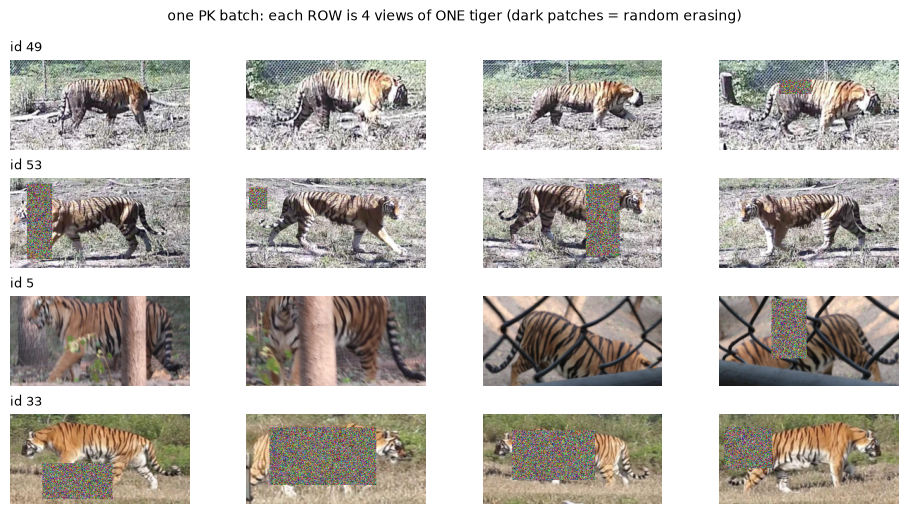

In [5]:
# Look at what we're feeding the network -- and at the PK structure, which is easier to
# understand as a picture than as a sampler class.
import matplotlib.pyplot as plt


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(4, K_IMGS, figsize=(2.4 * K_IMGS, 5.2))
for r in range(4):                                   # first 4 identities in the batch
    for c in range(K_IMGS):
        i = r * K_IMGS + c
        axes[r, c].imshow(unnormalize(xb[i]))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(f"id {int(yb[i])}", fontsize=9, loc="left")
plt.suptitle(f"one PK batch: each ROW is {K_IMGS} views of ONE tiger "
             f"(dark patches = random erasing)", fontsize=10)
plt.tight_layout(); plt.show()

# Section 2 — Helper functions, and why each exists

Five helpers. Two are familiar from `n4`; three exist only because the task changed from
classification to retrieval.

In [6]:
def count_params(model):
    """WHY: this is OSNet's headline claim. Running tally for the series: n2 AlexNet=61M,
    n3 VGG16=138M, n4 ResNet-18=11M (ResNet-50=25.6M). The paper's OSNet is 2.2M and beats
    ResNet-50-based ReID models. If our number is not around 2.2M, the architecture is wrong."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def extract_features(model, loader, flip_aug=False):
    """WHY: the single most important function in a re-ID notebook. Runs the backbone in eval
    mode and returns L2-NORMALIZED embeddings + their identity labels.

    L2 normalization matters: it puts every vector on the unit sphere, which (a) makes cosine
    similarity and Euclidean distance rank identically (d^2 = 2 - 2*cos), and (b) makes one
    global threshold meaningful across the whole gallery. Without it the network can lower the
    loss by inflating vector magnitude instead of improving direction."""
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        f = model(x, return_embedding=True)
        if flip_aug:                                  # cheap test-time trick, +0.5-1% typically
            f = f + model(torch.flip(x, dims=[3]), return_embedding=True)
        feats.append(F.normalize(f, dim=1).cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)


@torch.no_grad()
def evaluate_reid(model, query_loader, gallery_loader, topk=(1, 5, 10), flip_aug=False):
    """WHY: rank-k and mAP are what re-ID papers report, and they measure something CE accuracy
    cannot -- performance on identities the model never trained on.

    rank-k: is the correct identity somewhere in the top k retrieved gallery images?
    mAP:    averages precision over ALL correct matches, so a model that retrieves 1 of a
            tiger's 8 gallery photos scores far worse than one that retrieves all 8. A big
            rank-1/mAP gap means the model gets lucky rather than being reliable.

    SIMPLIFICATION: Market1501 protocol also discards gallery images taken by the same camera as
    the query. ATRW's reid split has no camera annotation, so that filter is absent and these
    numbers are slightly optimistic."""
    qf, q_pid = extract_features(model, query_loader, flip_aug)
    gf, g_pid = extract_features(model, gallery_loader, flip_aug)

    dist = 1.0 - qf @ gf.t()                          # cosine distance, both sides normalized
    order = dist.argsort(dim=1)
    matches = (g_pid[order] == q_pid[:, None])        # (n_query, n_gallery) boolean hit map

    cmc = {k: matches[:, :k].any(dim=1).float().mean().item() * 100 for k in topk}

    aps = []
    for row in matches:
        rel = row.float()
        n_rel = rel.sum()
        if n_rel == 0:
            continue
        cum = rel.cumsum(0)
        precision_at_hit = cum / torch.arange(1, len(rel) + 1, dtype=torch.float)
        aps.append(((precision_at_hit * rel).sum() / n_rel).item())
    mean_ap = 100.0 * sum(aps) / max(len(aps), 1)
    return cmc, mean_ap, (qf, q_pid, gf, g_pid, order)


@torch.no_grad()
def show_shapes(model):
    """WHY: verify the stage layout against the paper's Table 1. Only top-level stages are
    printed -- hooking every leaf module in OSNet would print several hundred lines."""
    x = torch.zeros(1, 3, IMG_H, IMG_W, device=DEVICE)
    print(f"{'input':14} {tuple(x.shape)}")
    hooks = []
    for name in ["conv1", "maxpool", "conv2", "conv3", "conv4", "conv5", "global_avgpool", "fc"]:
        mod = getattr(model, name, None)
        if mod is None:
            continue

        def hook(_m, _in, out, name=name):
            print(f"{name:14} {tuple(out.shape)}")
        hooks.append(mod.register_forward_hook(hook))
    model.eval(); _ = model(x, return_embedding=True)
    for h in hooks:
        h.remove()


def plot_history(history):
    """WHY: in re-ID the training loss and the metric you care about can diverge -- CE loss keeps
    falling on seen identities long after the embedding stops improving on unseen ones. Plotting
    both side by side is how you catch it."""
    _, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["rank1"] for h in history], marker="o", label="rank-1")
    ax[1].plot([h["mAP"] for h in history], marker="o", label="mAP")
    ax[1].set_title("retrieval on UNSEEN identities (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Section 3 — The architecture

## The shape of the idea

The paper's argument, in one sentence: **identity evidence lives at several spatial scales at once,
and a network that commits to one scale per layer cannot represent it.**

Their example (Fig. 1d) is a white T-shirt with a logo. The logo alone is not distinctive — lots of
clothes have logos. A white T-shirt alone is not distinctive — it is summer. It is the *combination*
of a small-scale feature and a medium-scale feature that identifies the person. The paper names
these two things:

- **homogeneous scale** — a feature at one receptive-field size (the logo; the T-shirt)
- **heterogeneous scale** — a feature that spans a *mixture* of sizes (the logo *on* the white shirt)

Both together are what they call **omni-scale**. For tigers the same structure appears: one stripe
fork is small-scale, the stripe layout along the flank is medium-scale, body shape and proportion is
large-scale, and "*that* fork pattern on *that* part of the flank" is heterogeneous.

A standard ResNet block has one receptive field. OSNet's block has four, plus a learned rule for
mixing them.

## Piece 1 — Lite 3×3 (why the model is 2.2M parameters)

A standard 3×3 conv from $c$ to $c'$ channels costs $9 \cdot c \cdot c'$ parameters. Split it into a
pointwise 1×1 (mixes channels, no spatial extent) and a depthwise 3×3 (spatial extent, no channel
mixing) and the cost becomes $(9 + c) \cdot c'$.

$$
\text{ReLU}(w * x) \;\longrightarrow\; \text{ReLU}((u \circ v) * x),
\qquad v \in \mathbb{R}^{1\times1\times c\times c'},\; u \in \mathbb{R}^{3\times3\times1\times c'}
$$

The paper is specific about the **order**: pointwise **then** depthwise, which is the reverse of
MobileNet's. Their reason (footnote 2) is that widening the channels *before* spatial aggregation
works better for omni-scale learning. Paper's own measurement: same architecture with standard
convs is 6.9M params / 3,384.9M mult-adds; with Lite 3×3 it is 2.2M / 978.9M — a 3× reduction.

Note the ablation result honestly: standard convs actually scored slightly *higher* (94.0 vs 93.6
rank-1, Table 5 model 2 vs 1). Lite 3×3 buys size, not accuracy.

## Piece 2 — the omni-scale residual block

Take a residual bottleneck and replace the single 3×3 path with $T$ parallel streams. Stream $t$ is
$t$ Lite 3×3 layers stacked, giving a receptive field of $(2t+1) \times (2t+1)$:

| stream | Lite 3×3 layers | receptive field |
|---|---|---|
| $t=1$ | 1 | 3×3 |
| $t=2$ | 2 | 5×5 |
| $t=3$ | 3 | 7×7 |
| $t=4$ | 4 | 9×9 |

$$
\tilde{x} = \sum_{t=1}^{T} F^{t}(x), \qquad y = x + \tilde{x}
$$

With $T=1$ this collapses back to an ordinary bottleneck. The paper uses $T=4$, and Table 5 shows
rank-1 climbing monotonically 86.5 → 91.7 → 92.8 → 93.6 as $T$ goes 1 → 2 → 3 → 4.

## Piece 3 — the unified aggregation gate (the actual contribution)

Summing the streams equally would give *multi-scale* features. What makes them *omni-scale* is that
the weights are computed **from the input image itself**:

$$
\tilde{x} = \sum_{t=1}^{T} G(x^{t}) \odot x^{t}, \qquad x^{t} \triangleq F^{t}(x)
$$

$G$ is a tiny sub-network: global average pool → FC (reduction 16) → ReLU → FC → sigmoid. It outputs
a **vector**, one weight per channel, not a scalar — so the fusion is per-channel, not per-stream.

Two design choices the paper defends with ablations:

- **Channel-wise, not stream-wise** gates: +1.0 rank-1 (model 7). Different channels encode
  different visual concepts and deserve different scale mixes.
- **Dynamic, not learned-and-then-frozen** gates: +2.0 rank-1 / +3.5 mAP (model 8). This is the one
  that matters for re-ID specifically — test images are of *identities not in training*, so the
  fusion rule has to adapt per input rather than be baked in.

And the gate is **shared across all four streams** ("unified"). Two reasons:

1. Parameter count becomes independent of $T$.
2. The gradient. With one shared $G$, backprop gives
   $\frac{\partial L}{\partial G} = \frac{\partial L}{\partial \tilde{x}} \left( \sum_{t=1}^{T} x^{t} \right)$
   — every stream's supervision signal trains the gate together. Give each stream its own gate and
   that property is lost; the paper measures −0.7 rank-1 despite *more* parameters (model 6).

Fusion strategy ablation, for context: concatenation 91.4, addition 92.0, unified AG **93.6**.

## The layers (paper Table 1, transposed for landscape tiger crops)

| Stage | What it is | Out (128×256 in) | Why |
|---|---|---|---|
| conv1 | 7×7 conv, stride 2 + 3×3 max-pool s2 | 3×128×256 → 64×32×64 | cheap early downsample |
| conv2 | 2 × OSBlock (64→256) | 64×32×64 → 256×32×64 | omni-scale features, fine spatial detail |
| transition | 1×1 conv + 2×2 avg-pool s2 | 256×32×64 → 256×16×32 | halve resolution between stages |
| conv3 | 2 × OSBlock (256→384) | 256×16×32 → 384×16×32 | mid-level structure |
| transition | 1×1 conv + 2×2 avg-pool s2 | 384×16×32 → 384×8×16 | halve resolution |
| conv4 | 2 × OSBlock (384→512) | 384×8×16 → 512×8×16 | strongest features |
| conv5 | 1×1 conv | 512×8×16 → 512×8×16 | channel mixing before pooling |
| gap | global average pool | 512×8×16 → 512 | **the image is now a vector** |
| fc | linear 512 → 512 | 512 → 512 | **the embedding — this is what ships** |
| *classifier* | *linear 512 → N_train_ids* | *→ 85* | *scaffolding; deleted after training* |

Note what is *not* here: no attention over body parts, no pose model, no horizontal stripe pooling,
no branch for local vs global regions. The paper's point is that stacking one well-designed block is
enough.

In [7]:
class Conv1x1(nn.Module):
    """1x1 conv + BN + ReLU. Used for channel manipulation, not spatial aggregation."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)), inplace=True)


class Conv1x1Linear(nn.Module):
    """1x1 conv + BN, NO activation. Residual branches end here so the sum happens
    pre-activation, exactly as in ResNet's bottleneck."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return self.bn(self.conv(x))


class LightConv3x3(nn.Module):
    """Paper Fig. 3(b): the 'Lite 3x3' layer. POINTWISE FIRST, then depthwise -- the paper is
    explicit that this order (not MobileNet's depthwise-first) works better here, because the
    channel width is increased before spatial aggregation."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.depthwise = nn.Conv2d(out_ch, out_ch, 3, padding=1, groups=out_ch, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.depthwise(self.pointwise(x))), inplace=True)


class LightConvStream(nn.Sequential):
    """Stream t = t stacked Lite 3x3 layers -> receptive field (2t+1)x(2t+1)."""

    def __init__(self, ch, depth):
        super().__init__(*[LightConv3x3(ch, ch) for _ in range(depth)])


class ChannelGate(nn.Module):
    """The Aggregation Gate, paper Eq. 3. GAP -> FC -> ReLU -> FC -> sigmoid, reduction 16.

    Output is a per-CHANNEL vector, not a scalar (paper: channel-wise beats stream-wise by ~1%),
    and it is computed FROM THE INPUT, so the scale mixture adapts to each image (paper: dynamic
    beats learned-and-frozen by 2.0 rank-1)."""

    def __init__(self, ch, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(ch, max(ch // reduction, 1), 1)
        self.fc2 = nn.Conv2d(max(ch // reduction, 1), ch, 1)

    def forward(self, x):
        g = self.pool(x)
        g = F.relu(self.fc1(g), inplace=True)
        return torch.sigmoid(self.fc2(g))            # (N, C, 1, 1) broadcast over H, W


class OSBlock(nn.Module):
    """Paper Fig. 4(b). T parallel streams of increasing receptive field, fused by ONE shared
    gate, wrapped in a residual bottleneck.

    `fuse` exists so Table 5's ablations are one keyword away:
      'unified'  -> paper's primary model                     (93.6 R1)
      'separate' -> one gate per stream, more params, worse    (92.9)
      'add'      -> plain sum, no gate                         (92.0)
      'concat'   -> concatenate then project                   (91.4)
    """

    def __init__(self, in_ch, out_ch, T=4, reduction=4, fuse="unified"):
        super().__init__()
        mid = out_ch // reduction
        self.T, self.fuse = T, fuse
        self.conv1 = Conv1x1(in_ch, mid)                              # squeeze
        self.streams = nn.ModuleList([LightConvStream(mid, t) for t in range(1, T + 1)])

        if fuse == "unified":
            self.gate = ChannelGate(mid)                              # ONE gate, shared
        elif fuse == "separate":
            self.gates = nn.ModuleList([ChannelGate(mid) for _ in range(T)])
        elif fuse == "concat":
            self.project = Conv1x1(mid * T, mid)

        self.conv3 = Conv1x1Linear(mid, out_ch)                       # restore
        self.downsample = Conv1x1Linear(in_ch, out_ch) if in_ch != out_ch else None

    def forward(self, x):
        identity = x
        x1 = self.conv1(x)

        outs = [s(x1) for s in self.streams]                          # T scales, same shape
        if self.fuse == "unified":
            x2 = sum(self.gate(o) * o for o in outs)                  # paper Eq. 3
        elif self.fuse == "separate":
            x2 = sum(g(o) * o for g, o in zip(self.gates, outs))
        elif self.fuse == "concat":
            x2 = self.project(torch.cat(outs, dim=1))
        else:                                                          # 'add'
            x2 = sum(outs)

        x3 = self.conv3(x2)
        if self.downsample is not None:
            identity = self.downsample(identity)
        return F.relu(x3 + identity, inplace=True)


class OSNet(nn.Module):
    """Paper Table 1. `width` is the paper's width multiplier beta (Table 6): 1.0 -> 2.2M params,
    0.25 -> 0.2M params and still 92.2 rank-1 on Market1501."""

    def __init__(self, n_classes, blocks=(2, 2, 2), channels=(64, 256, 384, 512),
                 feat_dim=512, T=4, fuse="unified", width=1.0):
        super().__init__()
        ch = [max(int(c * width), 8) for c in channels]

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, ch[0], 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(ch[0]), nn.ReLU(inplace=True))
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        def stage(n, cin, cout, reduce_size):
            layers = [OSBlock(cin, cout, T=T, fuse=fuse)]
            layers += [OSBlock(cout, cout, T=T, fuse=fuse) for _ in range(n - 1)]
            if reduce_size:                                # 'transition' rows in Table 1
                layers += [Conv1x1(cout, cout), nn.AvgPool2d(2, stride=2)]
            return nn.Sequential(*layers)

        self.conv2 = stage(blocks[0], ch[0], ch[1], True)
        self.conv3 = stage(blocks[1], ch[1], ch[2], True)
        self.conv4 = stage(blocks[2], ch[2], ch[3], False)
        self.conv5 = Conv1x1(ch[3], ch[3])

        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(ch[3], feat_dim)               # -> the 512-d embedding
        self.classifier = nn.Linear(feat_dim, n_classes)   # -> scaffolding, deleted at test time

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def featuremaps(self, x):
        x = self.maxpool(self.conv1(x))
        return self.conv5(self.conv4(self.conv3(self.conv2(x))))

    def forward(self, x, return_embedding=False):
        v = self.global_avgpool(self.featuremaps(x)).flatten(1)
        v = self.fc(v)                                     # 512-d embedding
        if return_embedding:
            # Inference path: the classifier is never touched. It has no output neuron for a
            # tiger it was not trained on -- which is the entire reason re-ID works.
            return v
        return v, self.classifier(v)

In [8]:
model = OSNet(n_classes=N_TRAIN_IDS).to(DEVICE)

print("trainable parameters:", f"{count_params(model):,}",
      "  <- paper reports 2.2M for OSNet x1.0 (Table 1)")
print("ResNet-50 for comparison: ~25,600,000\n")
show_shapes(model)

trainable parameters: 2,212,089   <- paper reports 2.2M for OSNet x1.0 (Table 1)
ResNet-50 for comparison: ~25,600,000

input          (1, 3, 128, 256)
conv1          (1, 64, 64, 128)
maxpool        (1, 64, 32, 64)
conv2          (1, 256, 16, 32)
conv3          (1, 384, 8, 16)
conv4          (1, 512, 8, 16)
conv5          (1, 512, 8, 16)
global_avgpool (1, 512, 1, 1)
fc             (1, 512)


## The losses

### Why there is no target embedding

This is the part that confuses everyone coming from classification, so it is worth stating flatly:

> **Nobody knows what tiger 42's embedding "should" be, and no such answer exists.**

Rotate the entire 512-d space and every distance is unchanged, so every rotation is an equally valid
solution. There is no ground-truth vector to regress towards. The supervision is *relational* — it
constrains distances *between* outputs, never an output against a stored answer.

```
classification:  loss(output, label)                     <- there is a target
metric learning: loss(output_a, output_p, output_n)      <- there is only a comparison
```

The identity label tells you *which images are groupable*. It never tells you *where the group goes*.

### What the paper actually uses

Softmax cross-entropy with **label smoothing**, and nothing else. Every identity is a class; the
classifier is trained; the classifier is thrown away; the 512-d `fc` output is used for retrieval.
This works because a feature good enough to separate 85 training identities generally transfers to
separating identities it has never seen.

Label smoothing replaces the hard one-hot target with
$q_i = (1-\varepsilon)\,\delta_{i,y} + \varepsilon/N$. Without it, cross-entropy pushes the correct
logit towards $+\infty$, which on a small dataset means memorising training identities — precisely
the failure mode that hurts on unseen ones.

### The optional addition: batch-hard triplet loss

Not in this paper, but the standard modern pairing, and a clean one-variable ablation:

$$
L = \max\big(0,\; d(a,p) - d(a,n) + \text{margin}\big)
$$

It optimises the geometry you actually deploy, whereas cross-entropy optimises separability in the
classifier's space and only *hopes* the embedding inherits it. **Batch-hard** mining means: for each
anchor in the batch, take the *furthest* same-identity image and the *nearest* different-identity
image. Random triplets satisfy the margin within a couple of epochs and then contribute exactly
zero gradient; hard ones keep teaching. This is what the PK sampler in Section 1 was built for.

For the animal case specifically, Schneider et al. (2022) compared contrastive vs. triplet loss on
five species including ATRW and found triplet won on every architecture and every dataset. Worth
running as `USE_TRIPLET = True` and putting in your results table.

In [9]:
class CrossEntropyLabelSmooth(nn.Module):
    """Paper's supervision (Sec 4.1), following Szegedy et al. eps=0.1.
    WHY: hard targets push the correct logit toward infinity, which on ~1.9k images means
    memorising the 85 training tigers -- exactly what does NOT transfer to unseen ones."""

    def __init__(self, n_classes, eps=0.1):
        super().__init__()
        self.n_classes, self.eps = n_classes, eps

    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=1)
        q = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
        q = (1 - self.eps) * q + self.eps / self.n_classes
        return (-q * logp).sum(dim=1).mean()


class BatchHardTripletLoss(nn.Module):
    """OPTIONAL -- not in the OSNet paper. Hermans et al. (2017) batch-hard mining.

    For each anchor: hardest positive = furthest same-id image in the batch,
                     hardest negative = nearest different-id image in the batch.
    Only works because the PK sampler guarantees K images per identity in every batch."""

    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, emb, labels):
        emb = F.normalize(emb, dim=1)
        dist = torch.cdist(emb, emb, p=2)                       # (B, B)
        same = labels[:, None] == labels[None, :]
        eye = torch.eye(len(labels), dtype=torch.bool, device=emb.device)

        d_ap = (dist.masked_fill(~same | eye, float("-inf"))).max(dim=1).values
        d_an = (dist.masked_fill(same, float("inf"))).min(dim=1).values
        valid = torch.isfinite(d_ap) & torch.isfinite(d_an)
        if valid.sum() == 0:
            return emb.new_zeros(())
        return F.relu(d_ap[valid] - d_an[valid] + self.margin).mean()


# --- the one-line ablation switch -------------------------------------------------------
USE_TRIPLET = False        # False = paper-faithful (CE + label smoothing only)
TRIPLET_WEIGHT = 1.0

ce_loss = CrossEntropyLabelSmooth(N_TRAIN_IDS)
tri_loss = BatchHardTripletLoss(margin=0.3)
print("supervision:", "CE(label-smoothed) + triplet" if USE_TRIPLET else "CE(label-smoothed)  [paper]")

supervision: CE(label-smoothed)  [paper]


## What one training step actually does

Same five lines as every notebook in this series, with one extra line if triplet is enabled:

```python
emb, logits = model(x)                        # 1. FORWARD (embedding AND class scores)
loss = ce_loss(logits, y)                     # 2. MEASURE THE ERROR
loss += tri_loss(emb, y)                      # 2b. optional, distance-based
optimizer.zero_grad()                         # 3. CLEAR OLD GRADIENTS
loss.backward()                               # 4. BACKWARD
optimizer.step()                              # 5. UPDATE THE WEIGHTS
```

The forward pass returns *two* things, and only the first one survives to deployment. Run the cell
below to watch a single weight move.

In [10]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.065, momentum=0.9, weight_decay=5e-4)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

w = model.conv1[0].weight                      # first 7x7 stem kernel
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)

model.train()
emb, logits = model(x)
loss = ce_loss(logits, y)
if USE_TRIPLET:
    loss = loss + TRIPLET_WEIGHT * tri_loss(emb, y)

optimizer.zero_grad(set_to_none=True)
loss.backward()
print("gradient after  backward():", w.grad[0, 0, 0, 0].item())

optimizer.step()
print(f"weight: {before:.6f} -> {w[0, 0, 0, 0].item():.6f}")
print("loss:", round(loss.item(), 4),
      f"| random-guess CE baseline ~ {torch.log(torch.tensor(float(N_TRAIN_IDS))).item():.3f}")
print("embedding shape:", tuple(emb.shape), "| logits shape:", tuple(logits.shape))

gradient before backward(): None
gradient after  backward(): -0.011008919216692448
weight: 0.031668 -> 0.032383
loss: 4.4204 | random-guess CE baseline ~ 4.443
embedding shape: (64, 512) | logits shape: (64, 85)


# Section 4 — Training

Paper-consistent choices (Sec 4.1, from-scratch setting): SGD with momentum, lr 0.065, weight decay
5e-4, batch 64, label smoothing, random flip + random erasing, step decay ×0.1.

**Adaptations, flagged:** the paper trains 350 epochs with drops at 150/225/300. Default here is 60
with drops scaled proportionally, plus a short linear warmup (from-scratch training at lr 0.065 on
a small dataset is otherwise prone to diverging in the first epochs). Expect numbers below the
paper's — the point is the comparison against `n4`, not the absolute value.

One thing to watch as it runs: **training accuracy on 85 seen identities and rank-1 on 22 unseen
identities are different curves.** When the first keeps climbing and the second flattens, the
network has started memorising rather than learning what "same tiger" means.

In [11]:
def fit(model, train_loader, query_loader, gallery_loader, epochs=60, lr=0.065,
        warmup_epochs=5, eval_every=5):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n8_osnet" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    # paper: drops at 150/225/300 of 350 -> same fractions of `epochs`
    milestones = [int(epochs * f) for f in (150 / 350, 225 / 350, 300 / 350)]
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

    amp_enabled = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []
    steps_per_epoch = max(len(train_loader), 1)

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss, correct, seen = 0.0, 0, 0

        for it, (x, y) in enumerate(train_loader):
            # linear warmup -- from-scratch training at lr 0.065 is unstable in the first epochs
            if epoch <= warmup_epochs:
                frac = ((epoch - 1) * steps_per_epoch + it + 1) / (warmup_epochs * steps_per_epoch)
                for g in optimizer.param_groups:
                    g["lr"] = lr * frac

            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                emb, logits = model(x)
                loss = ce_loss(logits, y)
                if USE_TRIPLET:
                    loss = loss + TRIPLET_WEIGHT * tri_loss(emb.float(), y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            seen += len(y)

        if epoch > warmup_epochs:
            scheduler.step()

        rec = {
            "epoch": epoch,
            "train_loss": running_loss / max(seen, 1),
            "train_acc_seen_ids": 100.0 * correct / max(seen, 1),
            "rank1": None, "rank5": None, "mAP": None,
            "epoch_time_sec": round(time.time() - epoch_start, 2),
            "lr": optimizer.param_groups[0]["lr"],
        }

        # Retrieval eval is expensive (two full passes) -- run it periodically, not every epoch.
        if epoch % eval_every == 0 or epoch == epochs:
            cmc, mean_ap, _ = evaluate_reid(model, query_loader, gallery_loader)
            rec["rank1"], rec["rank5"], rec["mAP"] = cmc[1], cmc[5], mean_ap
        else:
            prev = [h for h in history if h["rank1"] is not None]
            if prev:
                rec["rank1"], rec["rank5"], rec["mAP"] = (prev[-1]["rank1"], prev[-1]["rank5"],
                                                          prev[-1]["mAP"])
            else:
                rec["rank1"] = rec["rank5"] = rec["mAP"] = 0.0

        history.append(rec)
        log_epoch_csv(rec)
        print(f"epoch {epoch:3d}  lr {rec['lr']:.4g}  loss {rec['train_loss']:.4f}  "
              f"train(seen ids) {rec['train_acc_seen_ids']:.2f}%  "
              f"| UNSEEN rank-1 {rec['rank1']:.2f}%  mAP {rec['mAP']:.2f}%  "
              f"({rec['epoch_time_sec']:.1f}s)")

    return history

In [12]:
model = OSNet(n_classes=N_TRAIN_IDS).to(DEVICE)      # fresh model
history = fit(model, train_loader, query_loader, gallery_loader, epochs=60, lr=0.065)

epoch   1  lr 0.013  loss 4.4420  train(seen ids) 1.56%  | UNSEEN rank-1 0.00%  mAP 0.00%  (54.4s)
epoch   2  lr 0.026  loss 4.3398  train(seen ids) 3.40%  | UNSEEN rank-1 0.00%  mAP 0.00%  (10.6s)
epoch   3  lr 0.039  loss 4.1434  train(seen ids) 3.53%  | UNSEEN rank-1 0.00%  mAP 0.00%  (10.6s)
epoch   4  lr 0.052  loss 3.8308  train(seen ids) 11.14%  | UNSEEN rank-1 0.00%  mAP 0.00%  (10.6s)
epoch   5  lr 0.065  loss 3.7243  train(seen ids) 12.16%  | UNSEEN rank-1 93.10%  mAP 66.72%  (9.3s)
epoch   6  lr 0.065  loss 3.4296  train(seen ids) 13.38%  | UNSEEN rank-1 93.10%  mAP 66.72%  (8.8s)
epoch   7  lr 0.065  loss 3.1486  train(seen ids) 24.39%  | UNSEEN rank-1 93.10%  mAP 66.72%  (8.3s)
epoch   8  lr 0.065  loss 2.9085  train(seen ids) 29.42%  | UNSEEN rank-1 93.10%  mAP 66.72%  (8.5s)
epoch   9  lr 0.065  loss 2.8649  train(seen ids) 32.47%  | UNSEEN rank-1 93.10%  mAP 66.72%  (8.1s)
epoch  10  lr 0.065  loss 2.6471  train(seen ids) 34.17%  | UNSEEN rank-1 95.69%  mAP 73.38%  (8.3

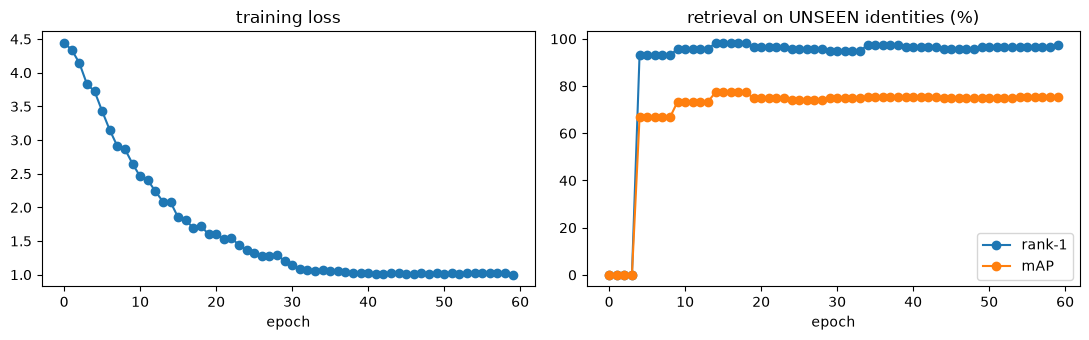

best rank-1 on unseen identities: 98.28 %
best mAP   on unseen identities: 77.41 %
random-guess rank-1 baseline: ~4.55%  (1 in 22 identities)

paper's Market1501 numbers, from scratch: 93.6 rank-1 / 81.0 mAP -- 12.9k training images,
751 identities, 350 epochs. Ours has ~1.5k images, 85 identities, 60 epochs. Different scale.


In [13]:
plot_history(history)
print("best rank-1 on unseen identities:", round(max(h["rank1"] for h in history), 2), "%")
print("best mAP   on unseen identities:", round(max(h["mAP"] for h in history), 2), "%")
print(f"random-guess rank-1 baseline: ~{100 / n_eval_ids:.2f}%  (1 in {n_eval_ids} identities)")
print("\npaper's Market1501 numbers, from scratch: 93.6 rank-1 / 81.0 mAP -- 12.9k training images,")
print("751 identities, 350 epochs. Ours has ~1.5k images, 85 identities, 60 epochs. Different scale.")

# Section 5 — Prediction and validation

`n4` validated with accuracy and a confusion matrix. Neither exists here — there are no classes to
confuse. Four checks instead, in increasing usefulness:

1. the retrieval metrics (rank-1/5/10, mAP) on identities never trained on,
2. *what* it retrieves — query image beside its top-5 gallery matches,
3. the **distance distributions**, which tell you whether a usable threshold exists at all,
4. the **activation maps**, which tell you *where* the omni-scale block is looking (paper Fig. 6).

Check 3 is the one that decides whether you can deploy. Check 4 is the one that tells you why.

In [14]:
cmc, mean_ap, (qf, q_pid, gf, g_pid, order) = evaluate_reid(model, query_loader, gallery_loader)

print("Held-out retrieval on identities the model has NEVER seen")
print("-" * 56)
for k, v in cmc.items():
    print(f"  rank-{k:<3} {v:6.2f}%")
print(f"  mAP     {mean_ap:6.2f}%")
print(f"\n  embedding dim: {qf.shape[1]}   queries: {len(q_pid)}   gallery: {len(g_pid)}")
print(f"  random-guess rank-1: ~{100 / n_eval_ids:.2f}%")
print("\nrank-1 much higher than mAP means the model often finds ONE correct match but not the")
print("rest -- reliable enough to answer 'who is this?', not yet enough to retrieve a full history.")

Held-out retrieval on identities the model has NEVER seen
--------------------------------------------------------
  rank-1    97.41%
  rank-5    99.14%
  rank-10  100.00%
  mAP      75.30%

  embedding dim: 512   queries: 116   gallery: 255
  random-guess rank-1: ~4.55%

rank-1 much higher than mAP means the model often finds ONE correct match but not the
rest -- reliable enough to answer 'who is this?', not yet enough to retrieve a full history.


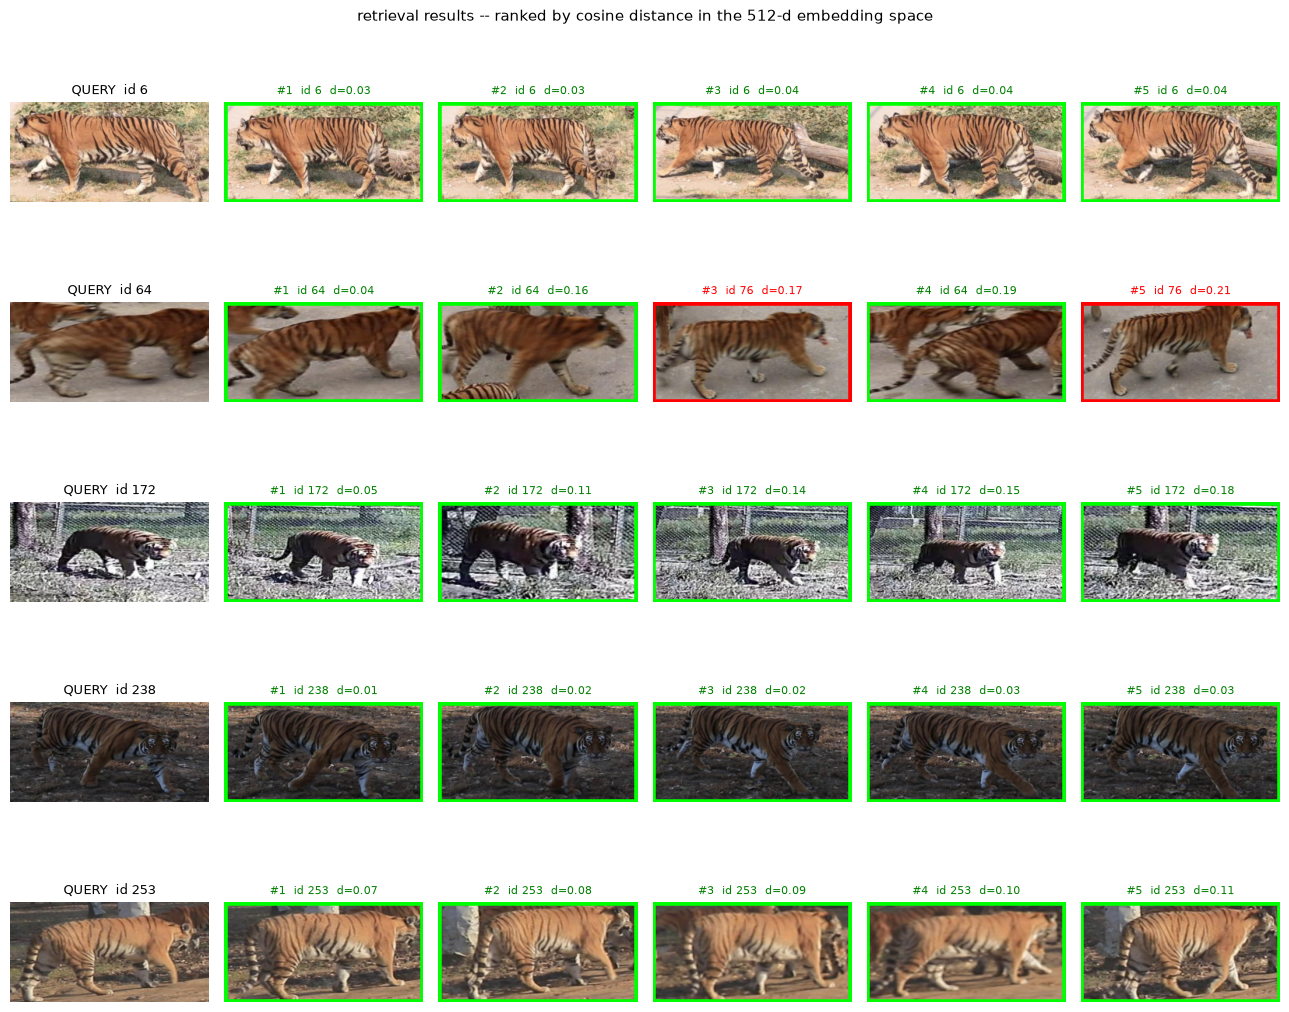

In [15]:
# What does it actually retrieve? Query on the left, top-5 gallery matches to the right.
# Green border = correct identity, red = wrong.
import matplotlib.patches as patches

n_show = 5
fig, axes = plt.subplots(n_show, 6, figsize=(13, 2.2 * n_show))
for r in range(n_show):
    qi = r * max(len(q_pid) // n_show, 1)
    qimg, _ = query_ds[qi]
    axes[r, 0].imshow(unnormalize(qimg)); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"QUERY  id {int(q_pid[qi])}", fontsize=9)

    for c in range(5):
        gi = order[qi, c].item()
        gimg, _ = gallery_ds[gi]
        hit = int(g_pid[gi]) == int(q_pid[qi])
        ax = axes[r, c + 1]
        ax.imshow(unnormalize(gimg)); ax.axis("off")
        ax.set_title(f"#{c+1}  id {int(g_pid[gi])}  d={1 - (qf[qi] @ gf[gi]).item():.2f}",
                     fontsize=8, color="green" if hit else "red")
        ax.add_patch(patches.Rectangle((0, 0), IMG_W - 1, IMG_H - 1, fill=False,
                                       edgecolor="lime" if hit else "red", linewidth=4))
plt.suptitle("retrieval results -- ranked by cosine distance in the 512-d embedding space",
             fontsize=11)
plt.tight_layout(); plt.show()

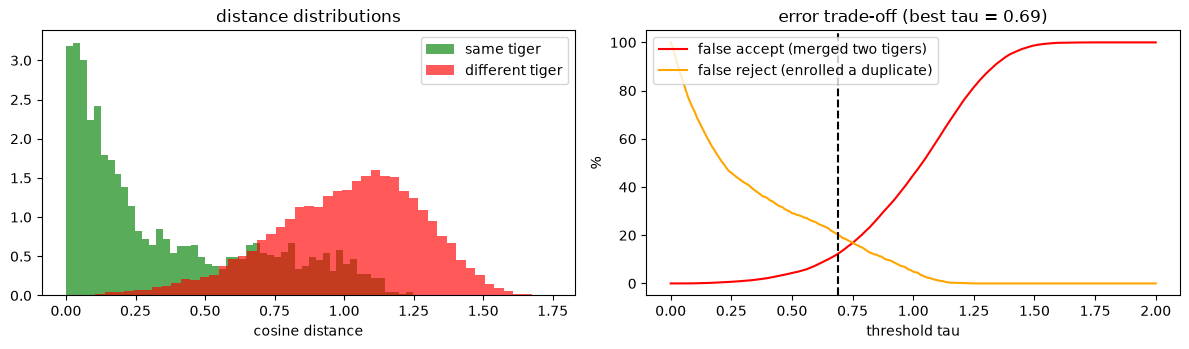

mean distance, same tiger:      0.352
mean distance, different tiger: 1.008
separation (higher is better):  0.656

at tau = 0.69:  false accept 12.3%   false reject 20.1%

On a real deployment these two errors are not equal. A false accept silently merges two
animals' records and corrupts everything downstream; a false reject just creates a
duplicate you can merge later. Bias tau LOW (strict) and accept the duplicates.


In [16]:
# The open-set question: is there a distance threshold that separates same-tiger pairs from
# different-tiger pairs? This plot is what decides whether the system can say "I don't know
# this animal" -- which a softmax classifier structurally cannot do.
d_all = 1.0 - qf @ gf.t()
same_mask = q_pid[:, None] == g_pid[None, :]
d_same = d_all[same_mask]
d_diff = d_all[~same_mask]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(d_same.numpy(), bins=50, alpha=0.65, label="same tiger", color="green", density=True)
ax[0].hist(d_diff.numpy(), bins=50, alpha=0.65, label="different tiger", color="red", density=True)
ax[0].set_xlabel("cosine distance"); ax[0].set_title("distance distributions"); ax[0].legend()

# Sweep the threshold: below tau -> "same", above -> "different / unknown".
taus = torch.linspace(0, 2, 201)
far = torch.tensor([(d_diff < t).float().mean() for t in taus])     # wrong match accepted
frr = torch.tensor([(d_same >= t).float().mean() for t in taus])    # right match rejected
ax[1].plot(taus, 100 * far, color="red", label="false accept (merged two tigers)")
ax[1].plot(taus, 100 * frr, color="orange", label="false reject (enrolled a duplicate)")
best = (far + frr).argmin()
ax[1].axvline(taus[best], ls="--", color="black")
ax[1].set_xlabel("threshold tau"); ax[1].set_ylabel("%"); ax[1].legend()
ax[1].set_title(f"error trade-off (best tau = {taus[best]:.2f})")
plt.tight_layout(); plt.show()

print(f"mean distance, same tiger:      {d_same.mean():.3f}")
print(f"mean distance, different tiger: {d_diff.mean():.3f}")
print(f"separation (higher is better):  {d_diff.mean() - d_same.mean():.3f}")
print(f"\nat tau = {taus[best]:.2f}:  false accept {100 * far[best]:.1f}%   "
      f"false reject {100 * frr[best]:.1f}%")
print("\nOn a real deployment these two errors are not equal. A false accept silently merges two")
print("animals' records and corrupts everything downstream; a false reject just creates a")
print("duplicate you can merge later. Bias tau LOW (strict) and accept the duplicates.")

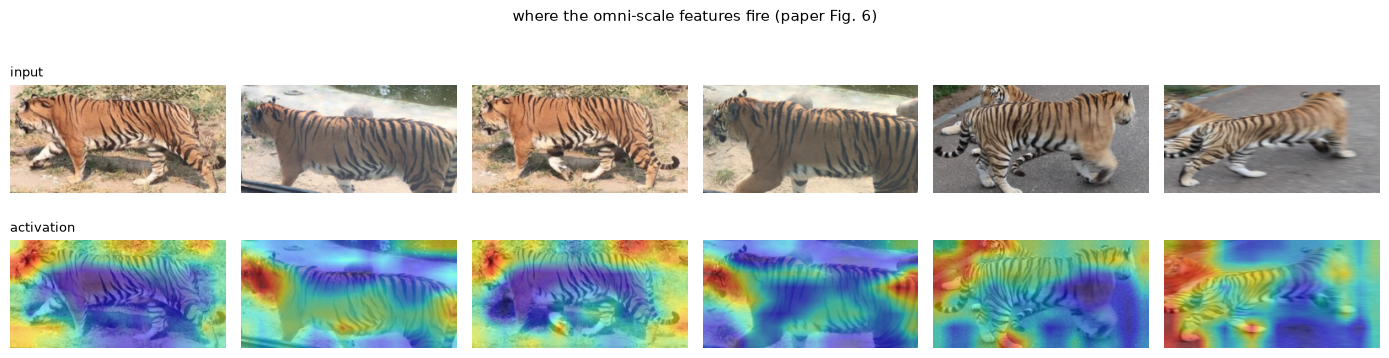

In [17]:
# Paper Fig. 6: activation maps. Sum |feature maps| over the channel dimension, then spatially
# L2-normalize -- this shows WHERE the network's evidence is concentrated. The paper uses it to
# argue that omni-scale features latch onto local discriminative patterns (a clothing logo)
# while a single-scale baseline over-focuses on one region.
@torch.no_grad()
def activation_map(model, x):
    model.eval()
    fm = model.featuremaps(x.to(DEVICE))              # (N, 512, h, w)
    a = fm.abs().sum(dim=1)                           # (N, h, w)
    a = a / (a.flatten(1).norm(dim=1).view(-1, 1, 1) + 1e-8)
    return a.cpu()


xq = torch.stack([query_ds[i][0] for i in range(6)])
amaps = activation_map(model, xq)

fig, axes = plt.subplots(2, 6, figsize=(14, 4))
for i in range(6):
    axes[0, i].imshow(unnormalize(xq[i])); axes[0, i].axis("off")
    axes[1, i].imshow(unnormalize(xq[i]))
    axes[1, i].imshow(torch.nn.functional.interpolate(
        amaps[i][None, None], size=(IMG_H, IMG_W), mode="bilinear",
        align_corners=False)[0, 0], cmap="jet", alpha=0.5)
    axes[1, i].axis("off")
axes[0, 0].set_title("input", fontsize=9, loc="left")
axes[1, 0].set_title("activation", fontsize=9, loc="left")
plt.suptitle("where the omni-scale features fire (paper Fig. 6)", fontsize=11)
plt.tight_layout(); plt.show()

gate vector shape (per image): (6, 128)
mean gate weight per image: [0.483, 0.488, 0.479, 0.488, 0.471, 0.476]
std ACROSS images (0 would mean the gate ignores its input): 0.0071


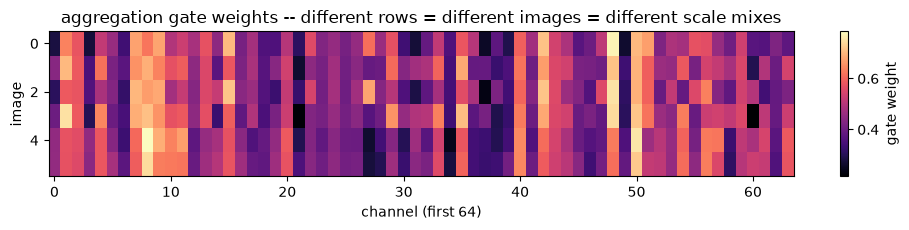

In [18]:
# What did the aggregation gate learn? Read the gate vectors out of the last OSBlock. If the
# gate were useless it would output near-identical weights for every image and every stream --
# so the spread across streams is a direct check that the omni-scale idea is doing something.
gate_out = {}


def capture(name):
    def hook(_m, _in, out):
        gate_out[name] = out.detach().flatten(1).cpu()
    return hook


last_block = [m for m in model.conv4.modules() if isinstance(m, OSBlock)][-1]
if last_block.fuse == "unified":
    h = last_block.gate.register_forward_hook(capture("gate"))
    with torch.no_grad():
        model.eval(); _ = model(xq.to(DEVICE), return_embedding=True)
    h.remove()

    g = gate_out["gate"]
    print("gate vector shape (per image):", tuple(g.shape))
    print("mean gate weight per image:", [round(v, 3) for v in g.mean(1).tolist()])
    print("std ACROSS images (0 would mean the gate ignores its input):",
          round(g.mean(1).std().item(), 4))
    plt.figure(figsize=(10, 2.4))
    plt.imshow(g[:, :64], aspect="auto", cmap="magma")
    plt.colorbar(label="gate weight"); plt.xlabel("channel (first 64)"); plt.ylabel("image")
    plt.title("aggregation gate weights -- different rows = different images = different scale mixes")
    plt.tight_layout(); plt.show()

# Section 6 — Glossary

Terms new to this notebook. See `n4`'s glossary for tensor, channel, kernel, convolution, stride,
padding, batch norm, ReLU, residual shortcut, global average pooling, epoch/batch, gradient,
backprop, overfitting, and `model.train()` / `model.eval()`.

**Re-identification (re-ID)** — deciding whether two observations show the same individual. Not
classification: the answer is a similarity, and the identities can be ones never seen in training.

**Embedding (feature vector, descriptor)** — the 512-d output of `fc`. Meaningless on its own;
meaningful only through distances to other embeddings.

**Embedding space / feature space** — the 512-d space the embeddings live in. Training reorganises
it so that distance corresponds to identity.

**Metric learning** — training a network by constraining distances between its outputs rather than
matching outputs to targets.

**Query** — the image being identified. **Gallery** — the database of enrolled images searched
against. **Probe** is a synonym for query.

**CMC / rank-k** — Cumulative Matching Characteristic. Rank-1 = the top retrieved gallery image has
the correct identity. Rank-5 = it appears somewhere in the top 5.

**mAP (mean average precision)** — precision averaged over *all* correct gallery matches for each
query, then averaged over queries. Punishes a model that retrieves one correct match and then drifts.

**Closed-set** — every test identity appeared in training. **Open-set** — test identities may be
entirely new, and the system must be able to answer "none of these".

**Identity-disjoint split** — train and test identity sets do not overlap. Required for an honest
re-ID number; splitting by image instead measures classification.

**PK sampling** — batches of P identities × K images, so every batch contains positive pairs.

**Anchor / positive / negative** — in a triplet: the reference image, another image of the same
identity, and an image of a different identity.

**Triplet loss** — `max(0, d(a,p) − d(a,n) + margin)`. Constrains *relative* order, not absolute
distance. **Batch-hard mining** picks the furthest positive and nearest negative in the batch.

**Margin** — the required gap between positive and negative distance. Too large and the network can
collapse every image to one point.

**Cosine similarity / distance** — `a·b / (‖a‖‖b‖)`, and `1 − cos`. With L2-normalized vectors it
ranks identically to Euclidean distance (`d² = 2 − 2·cos`) but the numbers are interpretable.

**L2 normalization** — scaling every embedding to unit length. Makes one global threshold meaningful
and stops the network raising magnitude instead of improving direction.

**Threshold τ** — the distance below which two embeddings are called the same individual. Chosen on
validation *after* training; it is not learned.

**Label smoothing** — softening the one-hot target to `(1−ε)` on the true class and `ε/N` elsewhere.
Prevents the overconfidence that makes features memorise training identities.

**Random erasing** — blanking a random rectangle of the input during training. Simulates occlusion.

---

**OSNet-specific terms**

**Depthwise separable convolution** — a 3×3 conv split into a 1×1 pointwise (channel mixing) and a
3×3 depthwise (spatial, one filter per channel). Cost drops from `9·c·c'` to `(9+c)·c'`.

**Lite 3×3** — the paper's version, pointwise **then** depthwise. The order is deliberate and the
reverse of MobileNet's.

**Stream / exponent t** — one branch of the block, built from `t` stacked Lite 3×3 layers, giving a
`(2t+1)×(2t+1)` receptive field. The paper uses T = 4 streams: 3×3, 5×5, 7×7, 9×9.

**Homogeneous scale** — a feature at a single receptive-field size. **Heterogeneous scale** — a
feature spanning a mixture of sizes. **Omni-scale** — both, learned together.

**Aggregation Gate (AG)** — GAP → FC → ReLU → FC → sigmoid, producing per-channel fusion weights
*from the input image*. **Unified** means one AG is shared by all streams, which keeps the parameter
count independent of T and lets every stream's gradient train the same gate.

**Dynamic vs. static fusion** — dynamic weights are recomputed per input; static ones are learned
then frozen. Paper measures +2.0 rank-1 for dynamic — the property that matters when test
identities are unseen.

**Transition** — the `1×1 conv + 2×2 average pool` pair between stages that halves resolution.

**Width multiplier β / resolution multiplier γ** — the two knobs for shrinking the model (Table 6).
β = 0.25 gives 0.2M parameters and still 92.2 rank-1 on Market1501.

## Next steps

Change **one** thing, re-run `fit`, log the result. Everything above the line is a paper ablation
you can reproduce; everything below is a step towards the cattle system.

### Reproduce the paper's ablations (Table 5 — Market1501 rank-1 in brackets)

| Try | Code | What it tells you |
|---|---|---|
| `T = 1` (single scale) [86.5] | `OSNet(..., T=1)` | how much of the accuracy is omni-scale at all — this is the single biggest number in the table |
| `T = 2` [91.7], `T = 3` [92.8] | `OSNet(..., T=2)` | whether the gain is monotonic on your data too |
| plain sum, no gate [92.0] | `OSNet(..., fuse="add")` | whether the *gate* matters or just the multiple scales |
| concatenate + project [91.4] | `OSNet(..., fuse="concat")` | why the paper rejected the obvious fusion |
| one gate per stream [92.9] | `OSNet(..., fuse="separate")` | that *more* parameters can be *worse* — the shared-gradient argument |
| shrink the model [92.2 at 0.2M] | `OSNet(..., width=0.25)` | the accuracy/size curve, i.e. what you could put on a Jetson |
| lower input resolution | `IMG_H, IMG_W = 96, 192` | the paper's γ multiplier; re-run Section 1 first |
| standard convs instead of Lite 3×3 [94.0] | swap `LightConv3x3` for a plain `nn.Conv2d(3×3)` | that Lite 3×3 buys size, not accuracy — the paper is honest about this and so should you be |

### Ablations specific to animals

| Try | What it tells you |
|---|---|
| turn off `RandomHorizontalFlip` | whether flipping is destroying asymmetric stripe/patch information — my prediction is it helps on tigers and hurts on some cattle |
| turn off `RandomErasing` | whether occlusion robustness is worth the harder optimization on a small dataset |
| `USE_TRIPLET = True` | the Schneider et al. result: triplet beat contrastive on ATRW for every architecture. Does adding it to CE help here? |
| `flip_aug=True` in `evaluate_reid` | free test-time gain, no retraining |
| ImageNet-pretrained init instead of from scratch | the paper reports both; on ~1.5k images this is usually the largest single jump available |
| vary `n_eval_ids` (22 → 10 → 40) | how much your rank-1 depends on how many identities it has to choose between. Report this, or your number is not comparable to anyone's |

### Towards the cattle system

| Step | Why |
|---|---|
| build a ResNet-50 + GAP re-ID baseline on this exact split | OSNet's value is only visible as a *delta*. Without the baseline, 2.2M params is a fact about nothing |
| evaluate `n4`'s trained classifier on these 22 unseen identities | the drop from closed-set to open-set is the most convincing number you will produce in this whole series |
| store multiple embeddings per identity, score by mean of top-3 | Schneider et al. found multi-image comparison measurably improves cattle re-ID |
| add the enrolment loop: two thresholds, a pending buffer, track-level voting | turns a brittle per-frame decision into a system that degrades gracefully |
| join to a detector (`n5`–`n7`) → crop → OSNet → gallery | the actual pipeline. Detection answers *where*, re-ID answers *which* |

Change one at a time and log it. That is what makes the results table mean anything.

## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel
restart and can be compared against the other notebooks later.

In [19]:
# Save the trained model + validation results into runs/n8_osnet/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n8_osnet"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

# The gallery embeddings ARE the identity database -- save them separately, because this is the
# artifact you would actually deploy alongside the weights.
torch.save({"embeddings": gf, "identities": g_pid}, RUN_DIR / "gallery.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "params": count_params(model),
        "input_hw": [IMG_H, IMG_W],
        "embedding_dim": int(qf.shape[1]),
        "train_identities": N_TRAIN_IDS,
        "eval_identities_unseen": n_eval_ids,
        "supervision": "CE+LS+triplet" if USE_TRIPLET else "CE+LS (paper)",
        "rank1": cmc[1], "rank5": cmc[5], "rank10": cmc[10], "mAP": mean_ap,
        "best_tau": float(taus[best]),
        "false_accept_at_best_tau": float(far[best]),
        "false_reject_at_best_tau": float(frr[best]),
        "history": history,
    }, f, indent=2)

print("saved model + gallery + metrics to", RUN_DIR.resolve())

saved model + gallery + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n8_osnet
